# Diabetes Risk Prediction System — Exploratory Data Analysis

This notebook performs exploratory data analysis on the Diabetes 130-US Hospitals dataset to identify important medical patterns, analyze feature relationships, detect missing values, and prepare the dataset for machine learning models.

Objectives:
- Understand dataset structure
- Detect missing values and anomalies
- Analyze feature distributions
- Identify class imbalance
- Discover relationships between medical attributes and diabetes outcomes
- Prepare preprocessing strategy

Import Libraries Properly

In [23]:
!pip install missingno

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)

Load Dataset

In [25]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

Dataset Overview

In [26]:
print("Dataset Shape:", df.shape)

Dataset Shape: (101766, 50)


Show Columns

In [27]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

Show Data Types

In [28]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

Dataset Info

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Statistical Summary

In [30]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Missing Value Analysis

In [31]:
df.replace("?", np.nan, inplace=True)

Count Missing Values

In [32]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

Missing Value Percentage

In [33]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

Missing Values Heatmap

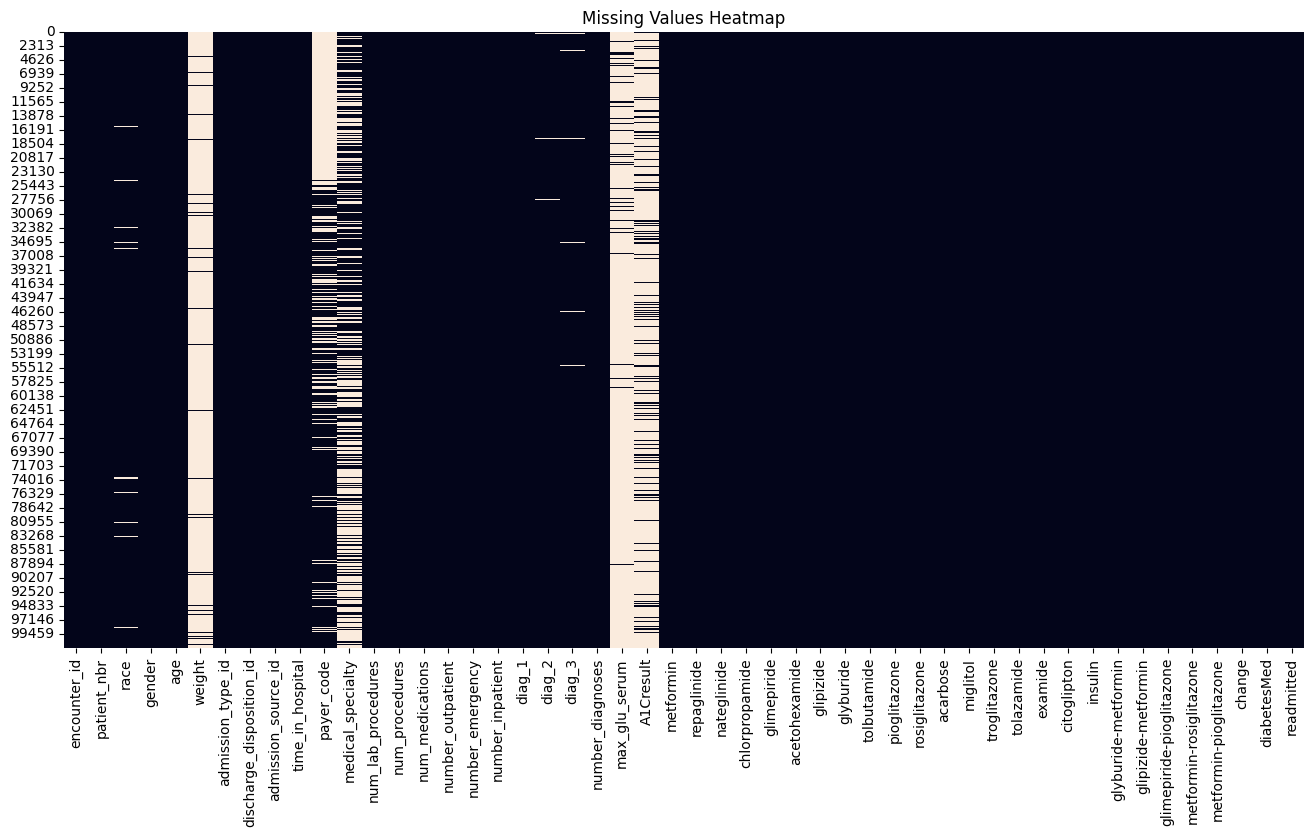

In [34]:
plt.figure(figsize=(16,8))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.savefig("../outputs/plots/missing_heatmap.png")

plt.show()

HIGH-QUALITY ADDITION

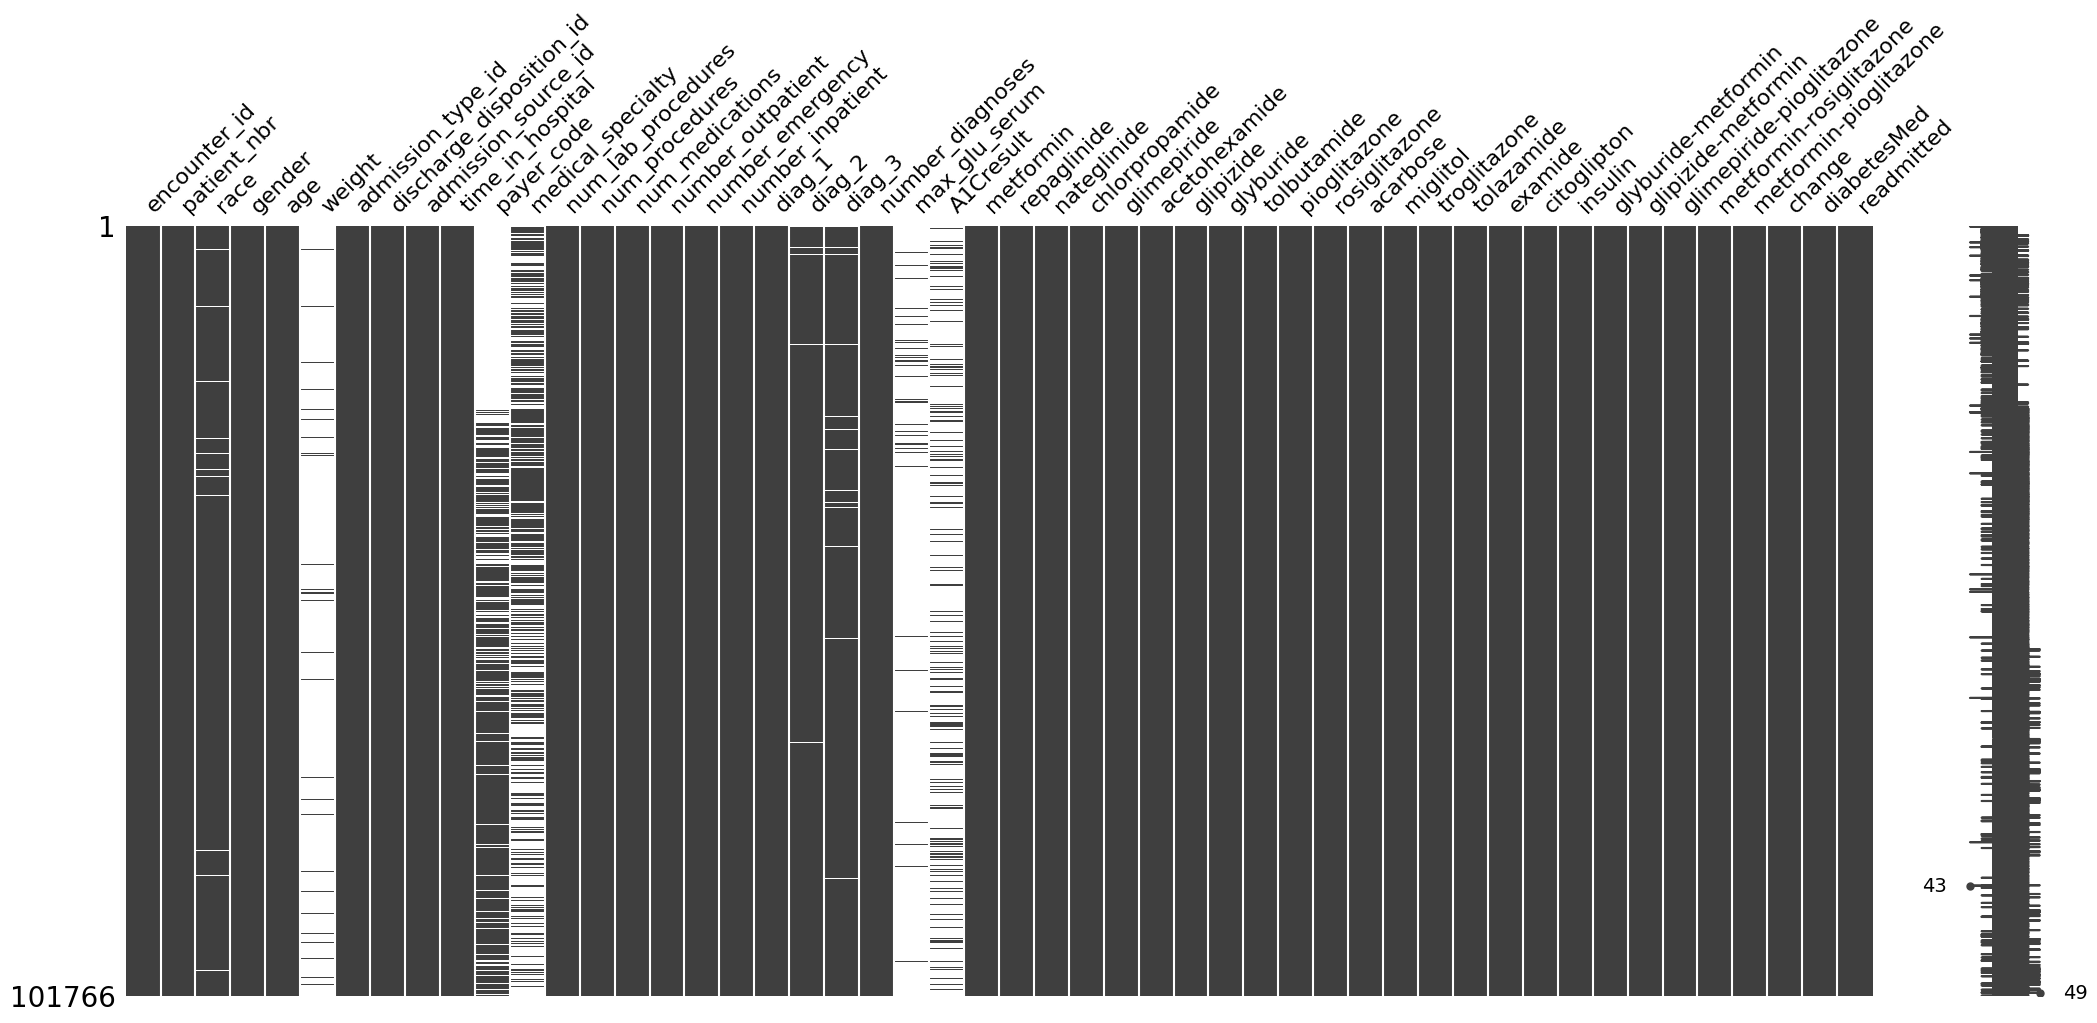

In [35]:
msno.matrix(df)

plt.savefig("../outputs/plots/missingno_matrix.png")

plt.show()

Class Distribution Analysis

In [36]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Class Distribution

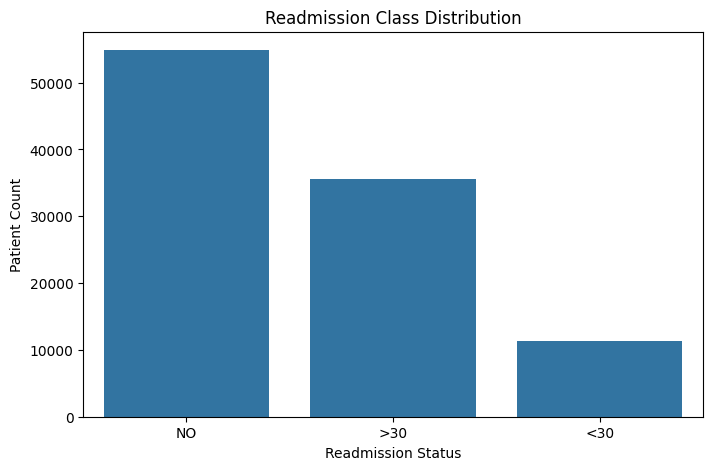

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(x="readmitted", data=df)

plt.title("Readmission Class Distribution")

plt.xlabel("Readmission Status")
plt.ylabel("Patient Count")

plt.savefig("../outputs/plots/readmission_distribution.png")

plt.show()

The dataset exhibits class imbalance, where certain diabetes outcome categories contain significantly more samples than others. This imbalance may negatively affect machine learning performance and therefore techniques such as SMOTE will be considered during preprocessing.

Age Distribution

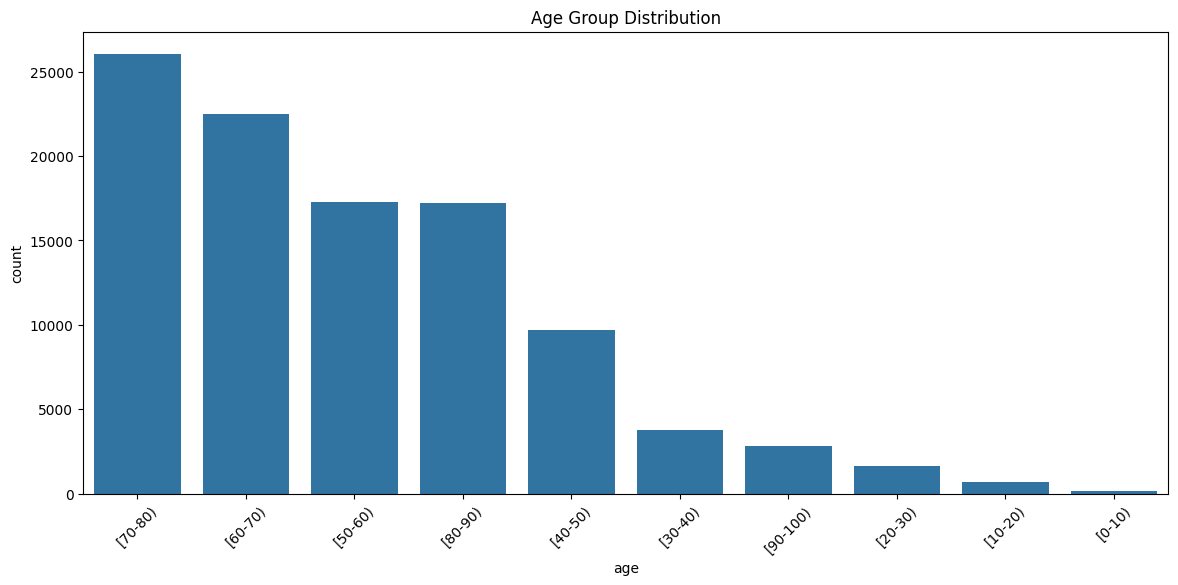

In [38]:
plt.figure(figsize=(14,6))

sns.countplot(
    x="age",
    data=df,
    order=df["age"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Age Group Distribution")

plt.savefig("../outputs/plots/age_distribution.png")

plt.show()

Glucose Distribution

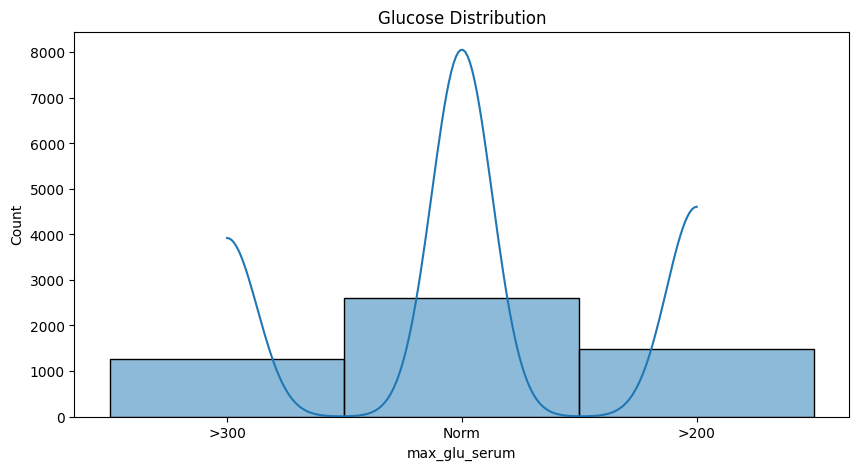

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(df["max_glu_serum"], kde=True)

plt.title("Glucose Distribution")

plt.savefig("../outputs/plots/glucose_distribution.png")

plt.show()

BMI Distribution

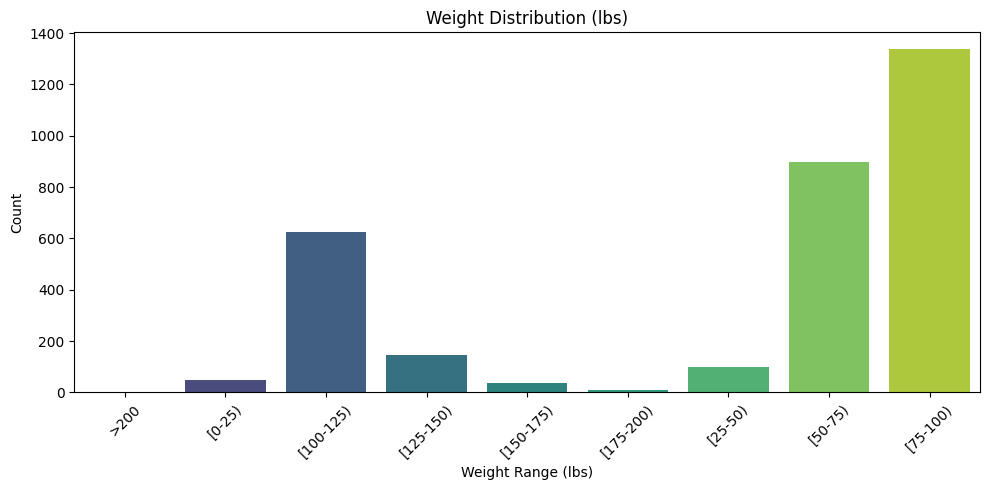

In [40]:
# Weight Distribution (dataset has 'weight' as categorical ranges, not numeric BMI)
plt.figure(figsize=(10, 5))

weight_counts = df[df["weight"].notna()]["weight"].value_counts().sort_index()

sns.barplot(x=weight_counts.index, y=weight_counts.values, palette="viridis")

plt.title("Weight Distribution (lbs)")
plt.xlabel("Weight Range (lbs)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/plots/weight_distribution.png")
plt.show()


Correlation Analysis

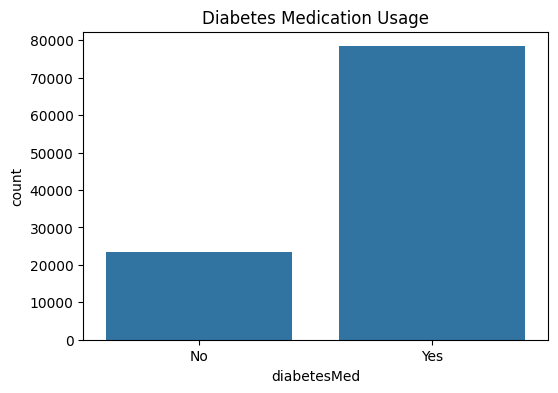

In [41]:
# Diabetes Medication Usage
plt.figure(figsize=(6,4))
sns.countplot(x="diabetesMed", data=df)
plt.title("Diabetes Medication Usage")
plt.savefig("../outputs/plots/diabetes_medication.png")
plt.show()

Correlation Heatmap

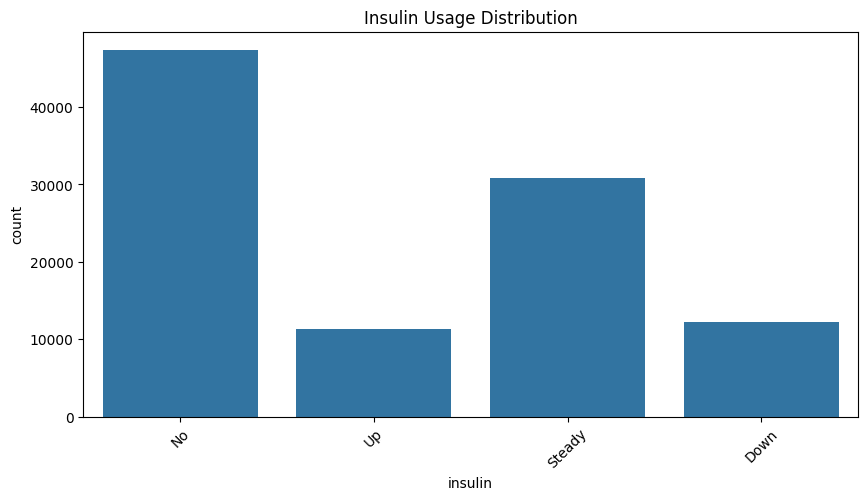

In [42]:
# Insulin Usage Analysis
plt.figure(figsize=(10,5))
sns.countplot(x="insulin", data=df)
plt.xticks(rotation=45)
plt.title("Insulin Usage Distribution")
plt.savefig("../outputs/plots/insulin_distribution.png")
plt.show()

Outlier Analysis (HIGH VALUE)

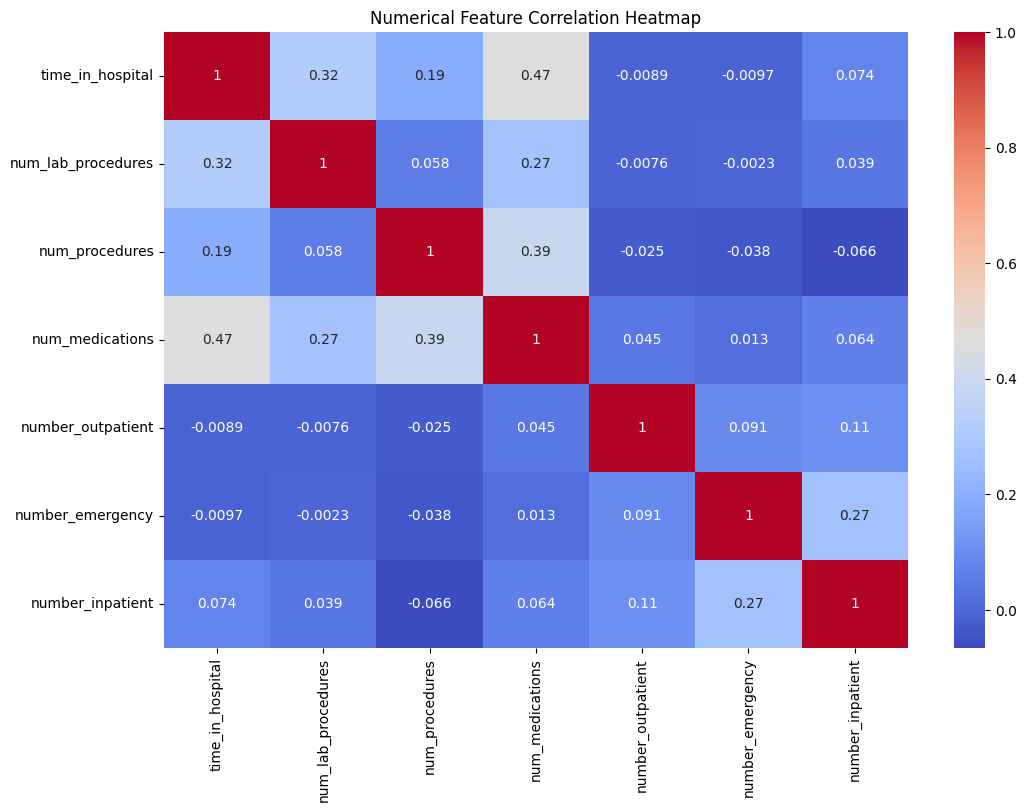

In [43]:
# Correlation Heatmap (Numerical Features Only)
numerical_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]
numerical_df = df[numerical_cols]
plt.figure(figsize=(12,8))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")
plt.title("Numerical Feature Correlation Heatmap")
plt.savefig("../outputs/plots/correlation_heatmap.png")
plt.show()

Feature Relationship Analysis

Age vs Diabetes Outcome

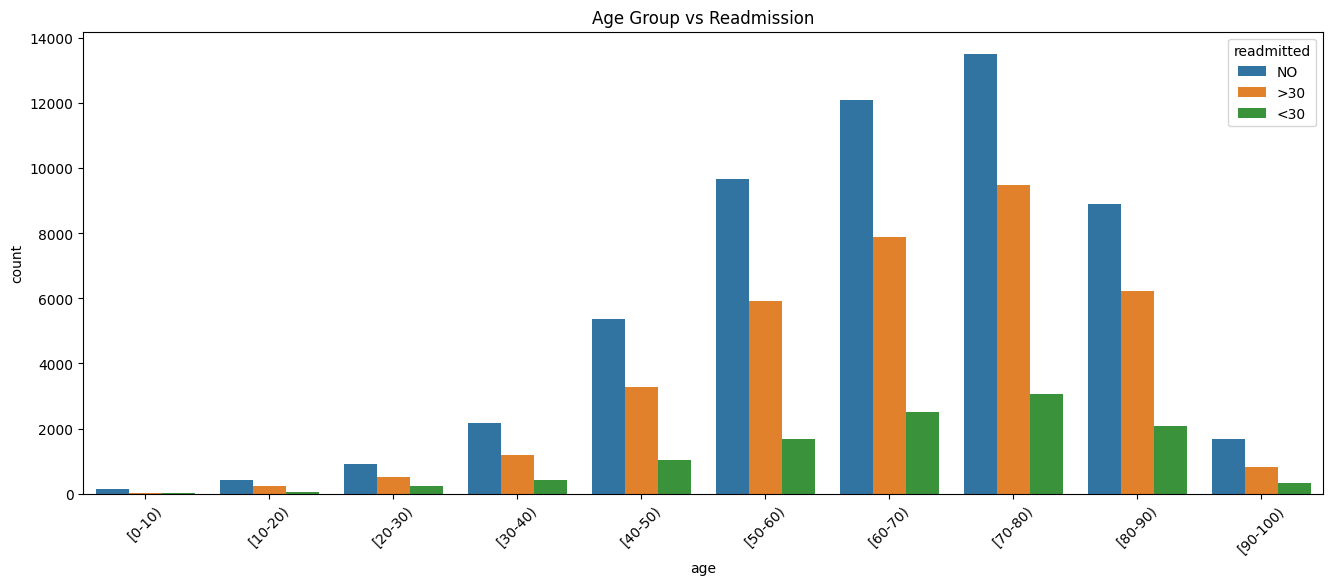

In [44]:
# Age vs Readmission
plt.figure(figsize=(16,6))
sns.countplot(
    x="age",
    hue="readmitted",
    data=df
)
plt.xticks(rotation=45)
plt.title("Age Group vs Readmission")
plt.savefig("../outputs/plots/age_vs_readmission.png")
plt.show()

Medications vs Outcome

<Axes: xlabel='readmitted', ylabel='num_medications'>

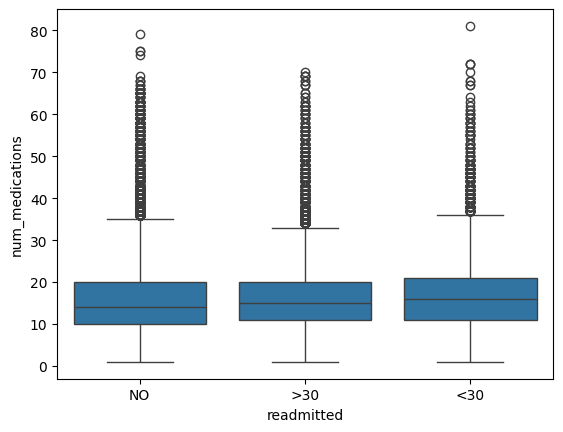

In [45]:
sns.boxplot(
    x="readmitted",
    y="num_medications",
    data=df
)

Age vs Readmission

<Axes: xlabel='age', ylabel='count'>

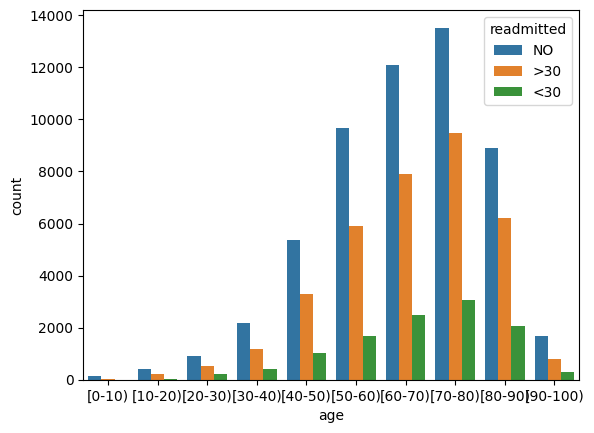

In [47]:
sns.countplot(
    x="age",
    hue="readmitted",
    data=df
)

Medication Count vs Readmission

<Axes: xlabel='readmitted', ylabel='num_medications'>

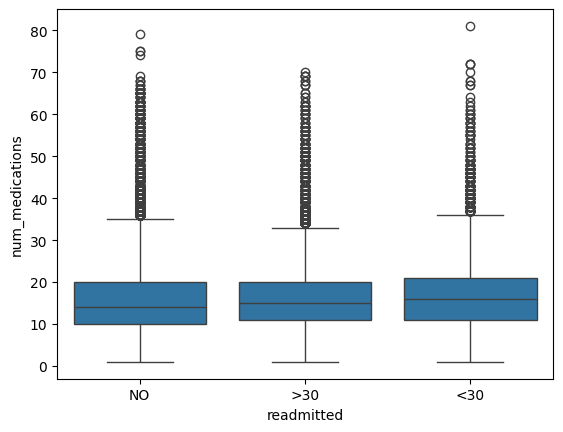

In [48]:
sns.boxplot(
    x="readmitted",
    y="num_medications",
    data=df
)

Hospital Stay vs Readmission

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

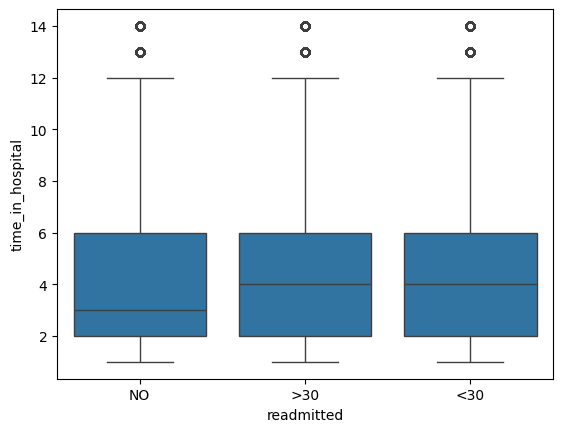

In [49]:
sns.boxplot(
    x="readmitted",
    y="time_in_hospital",
    data=df
)

Time in Hospital vs Outcome

Diabetes Medication vs Readmission

<Axes: xlabel='diabetesMed', ylabel='count'>

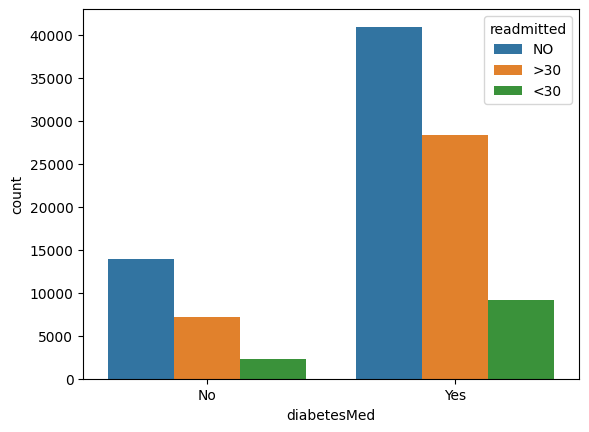

In [50]:
sns.countplot(
    x="diabetesMed",
    hue="readmitted",
    data=df
)

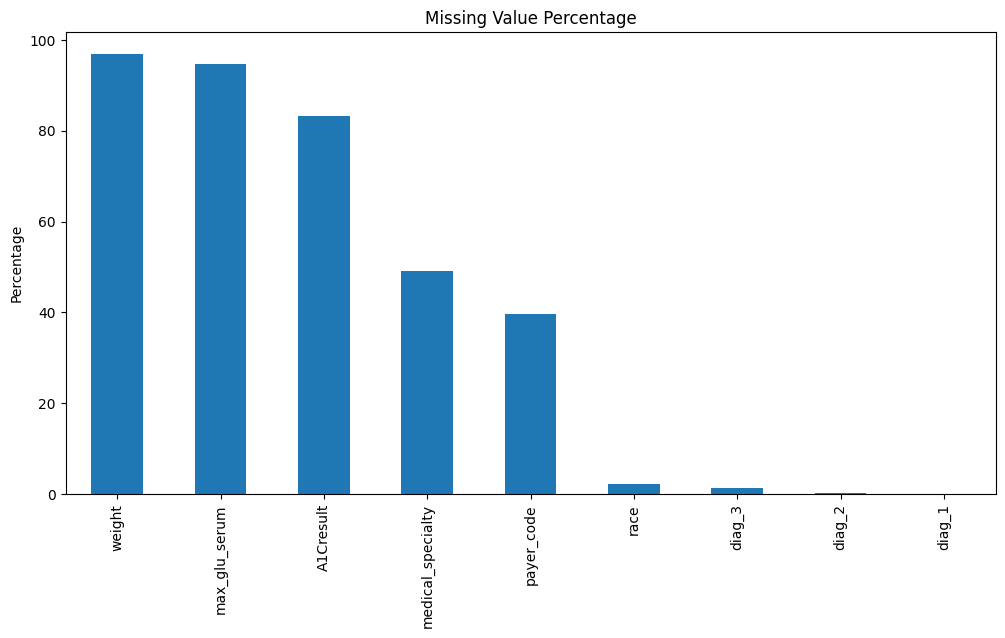

In [46]:
# Missing Value Analysis
import numpy as np
df.replace("?", np.nan, inplace=True)
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(12,6))
missing_percentage.plot(kind="bar")
plt.title("Missing Value Percentage")
plt.ylabel("Percentage")
plt.savefig("../outputs/plots/missing_percentage.png")
plt.show()

## Important EDA Insights

**Class Imbalance:**
The readmission classes are imbalanced, with the majority of patients belonging to the NO readmission category. This imbalance may bias machine learning models toward dominant classes, therefore oversampling techniques such as SMOTE will be considered during preprocessing.

**Age Analysis:**
Older age groups appear more frequently in the dataset and also exhibit higher readmission rates. This suggests that age may be an important predictive feature for diabetes-related hospitalization outcomes.

**Medication Analysis:**
Patients with higher numbers of medications tend to show more frequent readmission behavior, indicating increased medical complexity and disease severity.

# Preprocessing Decisions

Based on the exploratory data analysis:

1. Columns with extremely high missing percentages such as weight, max_glu_serum, and A1Cresult will be removed.

2. Missing values represented by '?' were converted to NaN.

3. Identifier columns such as encounter_id and patient_nbr will be removed.

4. Numerical features will be scaled using StandardScaler.

5. Categorical features will be encoded using Label Encoding or One-Hot Encoding.

6. Class imbalance in readmission categories will be handled using SMOTE.

7. Readmission outcomes will be interpreted as healthcare risk categories for predictive modeling.